[[  0. 100.  90.  90.   5.   0.   0.]]
Date 28.0. ff_ph=99.986%. ff_sp=0.014%. ff_fc=0.000%. ff_pl=0.000%. [28/28]%000%. [27/28]%% 0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
0


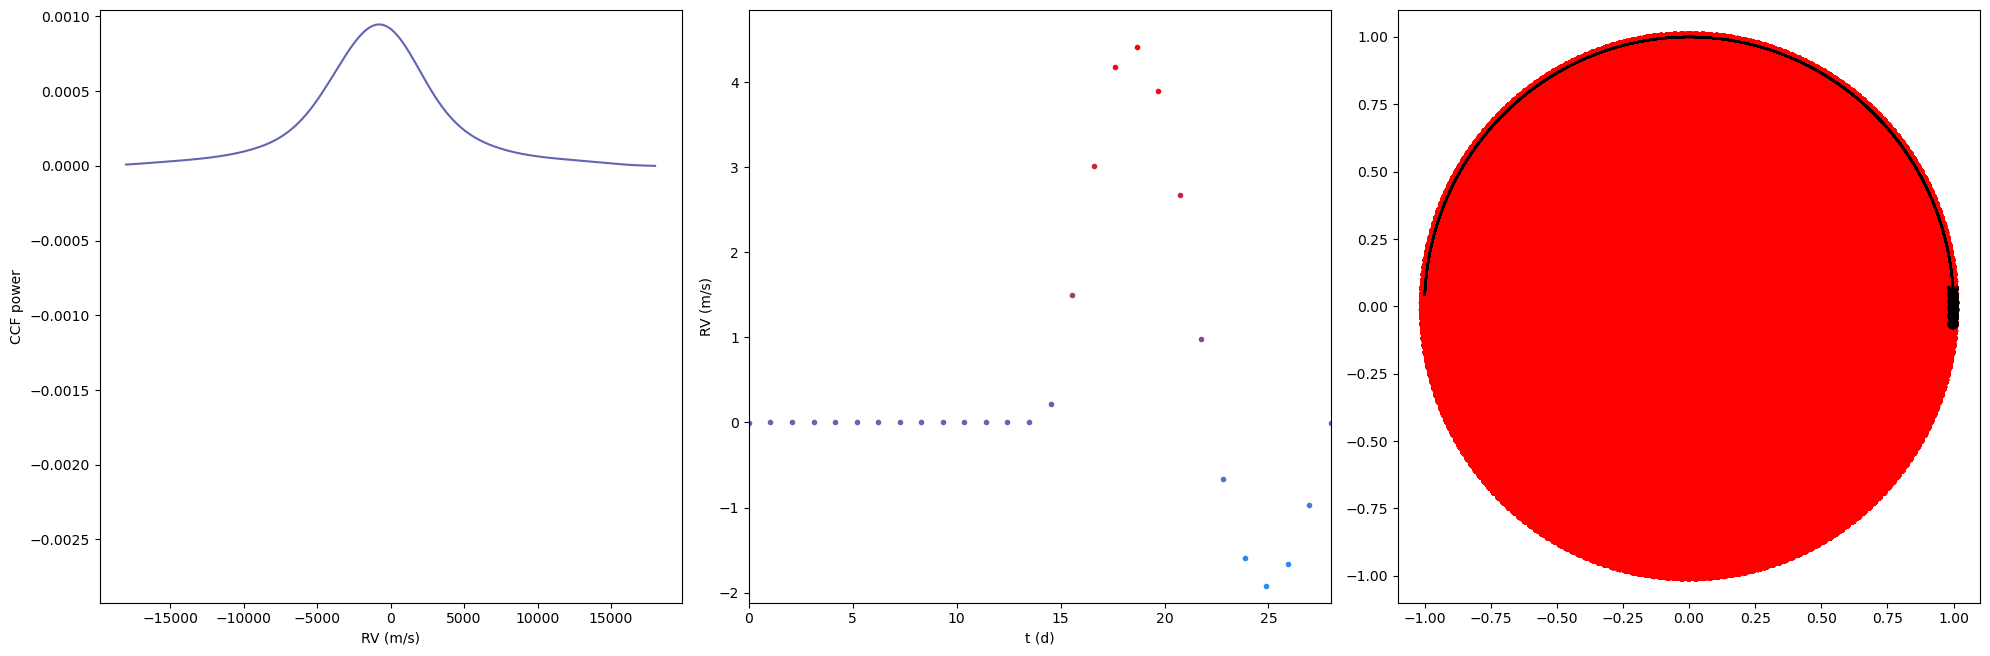

In [4]:
# -*- coding: utf-8 -*-
"""
Created on Fri Feb  2 11:59:16 2024

@author: blanc
"""
import starsim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import CubicSpline
import matplotlib.colors as mcolors

pathdata="/media/sophie-stucki/SD_phd/starsim_/starsim/results/"
path_grid="/home/sophie-stucki/starsim/starsim/gif/"
conf_file_path = "/media/sophie-stucki/SD_phd/starsim_/starsim/starsim.conf"
ss=starsim.StarSim(conf_file_path=conf_file_path)

'''
Generate 2 active longitudes in Starsim
'''

T_eff=5778
T_con=663
T_fac=30
Q=0
cs=1
radius=1
rot=28

t1=np.linspace(0,rot,num=28)

ss.spot_T_contrast=T_con
ss.facula_T_contrast=T_fac
ss.convective_shift=cs
ss.temperature_photosphere=T_eff
ss.rotation_period=rot
ss.radius=radius
ss.facular_area_ratio=Q
ss.inclination=0

overlap=True
tmin,tmax=t1.min(),t1.max()
k=0
while overlap:
    Nspots=1#np.random.randint(15,20)
    longitude=[90,270]
    ss.spot_map=np.zeros([Nspots,7])
    for j in range(Nspots):
        ss.spot_map[j][1]=100#lifetime spot
        ss.spot_map[j][0]=0#appearance time
        ss.spot_map[j][2]=90#latitude (degrees) [0,180]
        ss.spot_map[j][3]=longitude[j]#longitude (degrees)	[0,360]
        ss.spot_map[j][4]=5#spot size (degrees)
    overlap=starsim.nbspectra.check_spot_overlap(ss.spot_map,Q) #true if spots are overlapping
    print(ss.spot_map)
    #checks if the are overlapping spots. If true, find another set of spot parameters
    
ss.compute_forward(observables=['rv','lc'],t=t1)

rv_sim=ss.results['rv']
CCF=ss.results['CCF'][1:]
RV=ss.results['CCF'][0]
#%%
'''
Generate an animated GIF
'''

function1 =CCF[:]-np.mean(CCF,axis=0)

x1=RV[:]
lags = np.arange(len(t1))

# Define the colors
colors  = ["dodgerblue","r"]  # Red -> Black -> Blue

# Create a colormap from the list of colors
colormap = mcolors.LinearSegmentedColormap.from_list("BlueRed", colors)

# Normalize the continuous variable to map it to the range [0, 1] for the colormap
norm = Normalize(vmin=np.min(rv_sim), vmax=np.max(rv_sim))
scalar_map = ScalarMappable(norm=norm, cmap=colormap)

fig, ax = plt.subplots(ncols=3,figsize=(30/1.5, 10/1.5))

def update(frame):
    ax[0].cla()
    ax[1].cla()
    lag = lags[frame]
    print(lag)
    
    #plot RVs
    for i in range(len(t1)):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[1].plot(t1[i],rv_sim[i], color=color_val,marker='.')
    ax[1].set_xlim(t1.min(),t1.max())
    ax[1].set_ylim(rv_sim.min()-np.abs(rv_sim.min())/10,rv_sim.max()+np.abs(rv_sim.max())/10)
    ax[1].plot(t1[:lag],rv_sim[:lag],color='gray')
    
    #plot CCF
    color_val = scalar_map.to_rgba(rv_sim[lag])
    ax[0].plot(x1,function1[lag], color=color_val,alpha=1)
    for i in range(lag):
        color_val = scalar_map.to_rgba(rv_sim[i])
        ax[0].plot(x1,function1[i], color=color_val,alpha=0.1)
        
    #generate stellar grid
    x=np.linspace(-0.999,0.999,1000)
    h=np.sqrt((1-x**2)/(np.tan(0)**2+1))
    color_dict = { 0:'red', 1:'black', 2:'yellow', 3:'blue'}
    #0: photosphere, 1: spot, 2: faculae, 3: planet
    
    vec_grid=np.load(path_grid+'vec_gridt{:.4f}.npy'.format(t1[lag]))
    typ=np.load(path_grid+'typt{:.4f}.npy'.format(t1[lag]))
    
    #identifies which type of grid element is covering the pixel: photosphere, spot, facualae or planet
    ax[2].scatter(vec_grid[:,1],vec_grid[:,2], color=[ color_dict[np.argmax(i)] for i in typ ],s=50)
    ax[2].plot(x,h,'k')
    
    ax[0].set_ylabel('CCF power')
    ax[0].set_xlabel('RV (m/s)')
    ax[0].set_ylim(function1.min()-np.abs(function1.min())/10,function1.max()+np.abs(function1.max())/10)
    ax[1].set_ylabel('RV (m/s)')
    ax[1].set_xlabel('t (d)')
    fig.tight_layout()
    
# Create an animation
ani = FuncAnimation(fig, update, frames=len(lags), repeat=False)

# Save the animation as a video
writer = FFMpegWriter(fps=3, metadata=dict(artist='Me'), bitrate=2400)
ani.save(pathdata+"Sun_demo.gif", writer=writer)

In [ ]:
#add flux intenisty, bisector?